In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from core.data import CompressionMetrics
from core.utils import make_dual_update, round_sig
from core.video import reconstruct_video, compress_video

### Import the video

In [12]:
video_raw = iio.imread("../sources/drosophila_1slice.y4m")
video_raw = video_raw[:, :, :, 0]
nx, ny = 100, 100
video = video_raw[:, :nx, :ny]

# To view the first frame
# plt.imshow(video[0], cmap="gray")
# plt.show()

In [13]:
# Hyperparameters
lp_degree = 1.0
block_size = 10
cutoff = None
poly_degree = 5
t_degree = 20

In [14]:
c_t, X_design, t_design_matrix, rescale = compress_video(
    video, poly_degree, t_degree, block_size, lp_degree, lasso=False, cutoff=cutoff
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  90 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 3082 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 3100 out of 3100 | elapsed:    2.0s finished


In [15]:
c_t = round_sig(c_t)
video_rec = reconstruct_video(
    video, block_size, c_t, X_design, t_design_matrix, rescale
)

In [16]:
# Saving coefficients
np.save("../results/video/drosophila_video_full_01/coefficients/coefficients__bs=%s__cutoff=%s__lp=%s__poly_deg=%s__t_degree=%s__dtype=%s.npy" %
(block_size, cutoff, lp_degree, poly_degree, t_degree, c_t.dtype), c_t, allow_pickle=False)

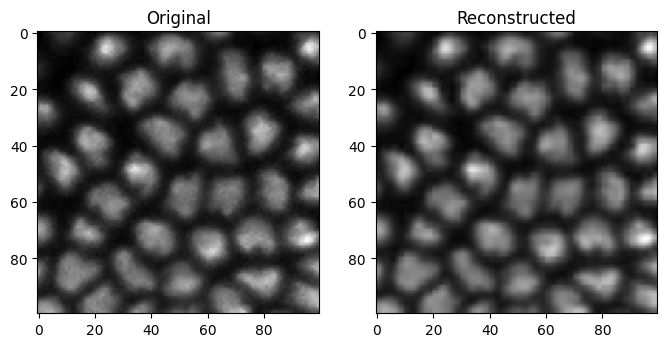

In [17]:
# To view video: calling make_update function defined in utils.py - next cell plays the video
fig, ax = plt.subplots(1, 2, figsize=(8,4))

im_orig = ax[0].imshow(video[0], cmap='gray')
ax[0].set_title("Original")

im_rec = ax[1].imshow(video_rec[0], cmap='gray')
ax[1].set_title("Reconstructed")

update = make_dual_update(video, video_rec, im_orig, im_rec)
ani = animation.FuncAnimation(fig, update, frames=len(video), interval=200, blit=True)

In [18]:
from IPython.display import HTML
HTML(ani.to_jshtml())

In [19]:
metrics_vid = CompressionMetrics(video, video_rec, c_t)

In [20]:
import pandas as pd
idx_met = metrics_vid
metrics_vid_dict = {
    "Metric": ["Nonzero Coefficients (%)", "MSE", "PSNR (dB)", "Compression Ratio (%)", "Space Saved (%)", "SSIM"],
    "Value": [idx_met.nz_percent, idx_met.mse, idx_met.psnr, idx_met.compression_ratio, idx_met.space_saved, idx_met.ssim]
}
df = pd.DataFrame(metrics_vid_dict)
print(df)

                     Metric       Value
0  Nonzero Coefficients (%)  100.000000
1                       MSE   38.992492
2                 PSNR (dB)   32.220994
3     Compression Ratio (%)   14.225806
4           Space Saved (%)   85.774194
5                      SSIM    0.971989
